In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling.models import Sersic2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.constants import c
from reproject import reproject_interp
from scipy.optimize import minimize, least_squares
from scipy.signal import fftconvolve, convolve2d
import dynesty
import dynesty.pool as dypool
from dynesty import plotting as dyplot
import dynesty.utils as dyutil
import pickle
import corner
from cmcrameri import cm
from multiprocessing import Pool
import importlib
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
# seed the random number generator
rstate = np.random.default_rng(111)

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext
from glint.forward import forward_model_2D_image
from glint.inference import run_emcee
from glint.plotstyle import set_my_plot_style

In [2]:
set_my_plot_style()

In [3]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

## Select data for fitting

In [4]:
option = ["cont", "CII_mom0"]

fit_data = option[0]  # choose which data to fit

## Data

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


hst peak: 8.0, 17.0 pix, corresponding to 0.160, 0.340 arcsec from the center
hst centroid: 4.7, 3.5 pix, corresponding to 0.093, 0.070 arcsec from the center
hst gaussian fit: 10.8, 14.5 pix, corresponding to 0.217, 0.290 arcsec from the center
Number of pixels in the mask: 30164
Number of pixels in image plane: 201 x 201
Pixel scale in image plane: 0.02 arcsec/pixel


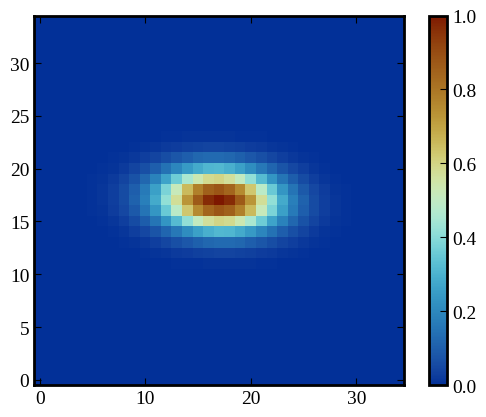

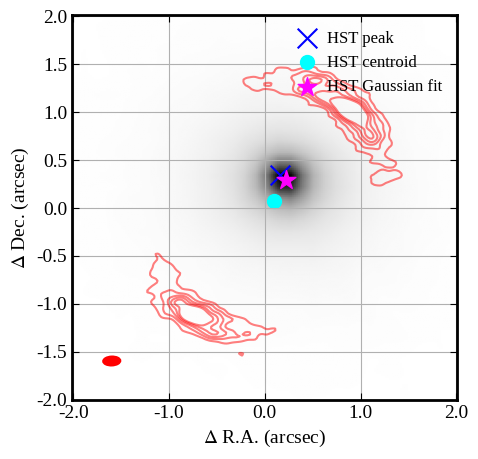

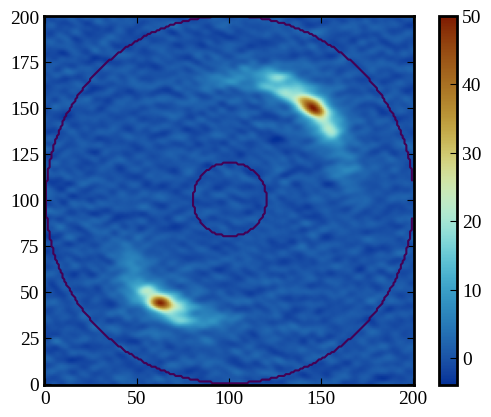

In [5]:
# image data
data_dir = Path("./data").resolve()
data_dir.exists()

obsfits   = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.image.pbcor.cutout.-250+300km.m0.fits")
noisefits = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.noise.pbcor.cutout.-250+300km.m0.fits")

obsdata, obsheader = fits.getdata(obsfits, header=True)
noisedata = fits.getdata(noisefits)
noisedata_inv = 1/noisedata



#### Continuum data for overlay ####
contfits   = str(data_dir / "B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits")
contnoisefits = str(data_dir / "B6_concat_cont_rob-0.5_clean.noise.pbcor.cutout.fits")

contdata, contheader = fits.getdata(contfits, header=True)
contnoisedata = fits.getdata(contnoisefits)
####

#### select data to fit ####
if fit_data == "cont":
    obsheader = contheader
else:
    obsheader = obsheader
beam = cleanbeam_from_header(35, obsheader)
BMAJ, BMIN, BPA, CDELT = obsheader['BMAJ'], obsheader['BMIN'], obsheader['BPA'], obsheader['CDELT2']
plt.imshow(beam, origin="lower", cmap=cm.roma_r)
plt.colorbar()
####

# あとは同じ
hst_fits = str(data_dir / "hst_skycell-p1356x14y05_wfc3_ir_f125w_coarse-all_drz.fits")
hst_data, hst_header = fits.getdata(hst_fits, header=True)
hst_wcs = WCS(hst_header)

# reproject to ALMA
hst_on_alma, footprint = reproject_interp((hst_data, hst_wcs), WCS(contheader, naxis=2), shape_out=contdata.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(hst_on_alma, origin='lower', cmap='gray_r')
ax.contour(contdata/contnoisedata, levels=[4,8,12,16,20], colors='red', alpha=0.5)

# 画像の中心
ny, nx = contdata.shape
x0 = (nx - 1) / 2
y0 = (ny - 1) / 2
pixscale_as = abs(obsheader['CDELT2'] * 3600) # arcsec/pix
def format_func_x(x_pix, _):
    return f"{(x_pix - x0) * pixscale_as:.1f}"
def format_func_y(y_pix, _):
    return f"{(y_pix - y0) * pixscale_as:.1f}"
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(format_func_x))
ax.yaxis.set_major_formatter(FuncFormatter(format_func_y))

# psfサイズをimage planeの左下に楕円として表示
xy_beam = (0.10*nx, 0.10*ny)
ellipse = Ellipse(xy=xy_beam, width=BMAJ/CDELT, height=BMIN/CDELT, angle=BPA+90, edgecolor='red', facecolor='red', lw=1.5)
ax.add_patch(ellipse)
ax.grid()

# HST peak
hst_peak = np.unravel_index(np.nanargmax(hst_on_alma), hst_on_alma.shape)
ax.scatter(hst_peak[1], hst_peak[0], marker='x', color='blue', s=200, label='HST peak')

# HST centroid
from photutils.centroids import centroid_com
y_com, x_com = centroid_com(hst_on_alma)
ax.scatter(x_com, y_com, marker='o', color='cyan', s=100, label='HST centroid')

# HST gaussian fit
def gauss2d(p, x, y):
    A, x0, y0, sx, sy, rho, c = p
    # 相関rho入り楕円ガウス：必要なければ rho=0 に固定
    X = (x - x0); Y = (y - y0)
    z = (X/sx)**2 + (Y/sy)**2 - 2*rho*X*Y/(sx*sy)
    return A*np.exp(-0.5/(1-rho**2) * z) + c
ny, nx = hst_on_alma.shape
yy, xx = np.indices((ny, nx))
p0 = [hst_on_alma.max(), x_com, y_com, 3.0, 3.0, 0.0, 0.0]
use = np.isfinite(hst_on_alma)
def resid(p): return (gauss2d(p, xx[use], yy[use]) - hst_on_alma[use])
res = least_squares(resid, p0, bounds=([0,0,0,0.5,0.5,-0.5,-np.inf],
                                       [np.inf,nx,ny,50,50,0.5,np.inf]))
A,x0_g,y0_g,sx,sy,rho,c = res.x
ax.scatter(x0_g, y0_g, marker='*', color='magenta', s=200, label='HST Gaussian fit')

ax.set_xlabel(r"$\Delta$ R.A. (arcsec)", fontsize=14)
ax.set_ylabel(r"$\Delta$ Dec. (arcsec)", fontsize=14)
ax.legend(fontsize=12)
print(f"hst peak: {hst_peak[1]-x0:.1f}, {hst_peak[0]-y0:.1f} pix, corresponding to {((hst_peak[1]-x0)*pixscale_as):.3f}, {((hst_peak[0]-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst centroid: {x_com-x0:.1f}, {y_com-y0:.1f} pix, corresponding to {((x_com-x0)*pixscale_as):.3f}, {((y_com-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst gaussian fit: {x0_g-x0:.1f}, {y0_g-y0:.1f} pix, corresponding to {((x0_g-x0)*pixscale_as):.3f}, {((y0_g-y0)*pixscale_as):.3f} arcsec from the center")

x0_l = (x0_g-x0)*pixscale_as
y0_l = (y0_g-y0)*pixscale_as


# mask definition
maskdata = np.zeros(contdata.shape).astype(bool)

# RMS基準にマスクを定義する場合
# thresh = 2
# maskdata[obsdata*noisedata_inv > thresh] = True

# 固定マスクを使う場合
# 円環マスク
r_inner = 0.4 # arcsec
r_outer = 2.0 # arcsec
y, x = np.indices(contdata.shape)
x_center = contdata.shape[1] / 2
y_center = contdata.shape[0] / 2
r = np.sqrt((x - x_center)**2 + (y - y_center)**2) * np.abs(CDELT) * 3600
maskdata[(r >= r_inner) & (r <= r_outer)] = True


Npix = np.nansum(maskdata)
print(f"Number of pixels in the mask: {Npix}")

# mask
# obsdata[maskdata==0] = np.nan
# noisedata_inv[maskdata==0] = np.nan

fig, ax = plt.subplots()
im = ax.imshow(contdata/contnoisedata, origin="lower", cmap=cm.roma_r)
ax.contour(maskdata)
fig.colorbar(im, ax=ax)



# source plane grid
ny_src, nx_src = 400, 400
pixsize_src = 0.005 # arcsec
x0_src, y0_src = 0.0, 0.0
xx_src, yy_src = ls.make_grid_arcsec(nx=nx_src, ny=ny_src, pixscale_arcsec=pixsize_src, x0_arcsec=x0_src, y0_arcsec=y0_src)

# image plane grid
ny_img, nx_img = obsdata.shape
pixsize_img = (np.abs(obsheader['CDELT2'])*3600).round(5)
print(f"Number of pixels in image plane: {nx_img} x {ny_img}")
print(f"Pixel scale in image plane: {pixsize_img} arcsec/pixel")
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = ls.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)

## Common setting

In [6]:
ctx = ImageContext(
    xx_img = xx_img,
    yy_img = yy_img,
    xx_src = xx_src,
    yy_src = yy_src,
    pixsize_img = pixsize_img,
    pixsize_src = pixsize_src,
    x0_src = x0_src,
    y0_src = y0_src,
    x0_l = x0_l,
    y0_l = y0_l,
    beam = beam
)

In [7]:
if fit_data == "cont":
    from cont_params import param_names, param_table
    data_to_fit = contdata
    noise_to_fit = contnoisedata
elif fit_data == "CII_mom0":
    from CII_mom0_params import param_names, param_table
    data_to_fit = obsdata
    noise_to_fit = noisedata

x0 = param_table[:,0]
lb = param_table[:,1]
ub = param_table[:,2]
ndim = len(lb)

## fitting

In [8]:
from glint.inference import run_least_squares

dof = np.sum(maskdata)
dof_inv = 1/dof

def residual(theta):
    model = forward_model_2D_image(theta, ctx)[2]
    diff = (obsdata - model) * noisedata_inv
    chi2 = np.sum(diff[maskdata]**2) * dof_inv
    return chi2


result = run_least_squares(residual, x0, lb, ub)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.2250e+00                                    1.54e+01    
       1              2         2.7717e+00      3.45e+00       3.28e-01       1.36e+01    
       2              5         2.1642e+00      6.08e-01       2.64e-01       1.02e+01    
       3              6         1.7641e+00      4.00e-01       3.13e-01       7.08e+00    
       4              7         1.7539e+00      1.02e-02       6.59e-01       1.12e+01    
       5              8         1.4443e+00      3.10e-01       9.15e-02       5.01e+00    
       6             10         1.3801e+00      6.42e-02       5.21e-02       2.89e+00    
       7             11         1.3368e+00      4.32e-02       1.39e-01       1.86e+00    
       8             13         1.3166e+00      2.03e-02       1.57e-02       1.82e+00    
       9             14         1.3028e+00      1.38e-02       2.61e-02       1.76e+00    

In [9]:
best_fit = result.x

# save


print("Best-fit parameters:}")
for name, val in zip(param_names, best_fit):
    print(f"{name}: {val:.4f}")

Best-fit parameters:}
x_s: 0.0382
y_s: 0.0327
F_0: 12.9797
ellip: 0.1592
pa_deg: 100.3814
r_eff: 0.2104
n: 0.5432
b: 1.2755
q_l: 0.9999
pa_l: 0.3746
log_gamma: -1.1716
pa_gamma: 1.0413


Saved to ./figure/maps_fit_G09_cont_lens_fix.pdf


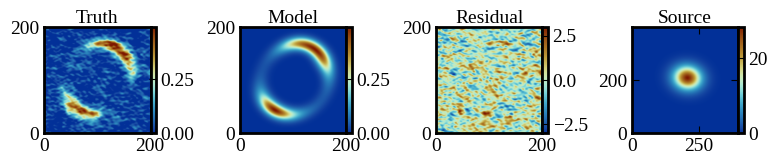

In [ ]:
# model with best-fit parameters
best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_2D_image(best_fit, ctx)

# Plot
# Some settings for plotting
vmax = np.nanmax(obsdata) * 0.9
width = 2
titles = ["Observation", "Model", "Residual", "Source"]


fig, axes = plt.subplots(1, 4, figsize=(width*4, width*1))
fig.subplots_adjust(wspace=0., hspace=0.0)
im0 = axes[0].imshow(obsdata, cmap=cm.roma_r, vmin=0, vmax=vmax, origin="lower")
# axes[0].contour(obsdata/noisedata, levels=[8,16,32], colors='black', linewidths=1.0)
im1 = axes[1].imshow(best_lensed_cube_conv, cmap=cm.roma_r,  vmin=0, vmax=vmax, origin="lower")
# im2 = axes[2].imshow((obsdata - best_lensed_cube_conv), cmap=cm.roma_r, vmin=-0.1*vmax, vmax=0.1*vmax, origin="lower")
im2 = axes[2].imshow((obsdata - best_lensed_cube_conv) / noisedata, cmap=cm.roma_r, vmin=-3, vmax=3, origin="lower")
im3 = axes[3].imshow(best_source, cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

for j in range(4):
    axes[j].set_title(titles[j], fontsize=14, pad=-2)
    divider = make_axes_locatable(axes[j])
    cax = divider.append_axes("right", size="5%", pad=0.)
    fig.colorbar([im0, im1, im2, im3][j], cax=cax)
    # axes[j].set_xticklabels([])
    # axes[j].set_yticklabels([])


savename = f"maps_fit_G09_{fit_data}_lens_fix"
fig.savefig(f"./figure/{savename}.pdf", dpi=200, bbox_inches="tight", pad_inches=0.05)
print(f"Saved to ./figure/{savename}.pdf")
plt.tight_layout()

In [11]:
from glint.inference import logprior_box


def loglike(theta):
    model = forward_model_2D_image(theta, ctx)[2]
    diff = (obsdata - model) * noisedata_inv
    chi2 = np.sum(diff[maskdata]**2)
    return -0.5 * chi2


def logprob(theta):
    lp = logprior_box(theta, lb, ub)
    if not np.isfinite(lp):
        return -np.inf
    ll = loglike(theta)
    return lp + ll

In [12]:
chain, logprob, sampler = run_emcee(logprob_fn=logprob, x0=best_fit, lb=lb, ub=ub, nwalkers=5*len(lb), burnin=1000, production=10000, ncpu=32, init_frac=0.2, skip_initial_state_check=False)


savename = f"./mcmc_chain_{fit_data}_mom0_image.npz"
np.savez(savename,
         chain=chain,
         logprob=logprob,
         param_names=param_names)

print(f"MCMC chain saved to {savename}.")

[init] min std over dims = 1.289e-01, median std = 1.615e-01


Running burn-in with 32 CPUs...


100%|██████████| 1000/1000 [00:50<00:00, 19.73it/s]


[burnin] acceptance mean = 0.219
[burnin] min std over dims = 3.841e-04, median std = 6.563e-03
Running production with 32 CPUs...


100%|██████████| 10000/10000 [07:11<00:00, 23.19it/s]



===== MCMC summary =====
steps (production): 10000 | walkers: 60 | ndim: 12
acceptance: mean=0.184, median=0.232, min=0.052, max=0.247
logprob (last step): finite fraction=1.000, median=-10119.212, max=-10113.443
worst 5 walkers (by last logprob): [8, 3, 53, 20, 7]
best  5 walkers (by last logprob): [36, 51, 5, 23, 46]
stationarity (|Δmean|/std in last half): median=0.29, max=0.70
autocorr time tau: median=799.5, max=1036.8
ESS: median=750, min=579
N/tau: median=12.5, min=9.6
===== end summary =====

MCMC chain saved to ./mcmc_chain_cont_mom0_image.npz.


## Corner plot

Loaded chain:
 chain shape: (10000, 60, 12)
 logprob shape: (10000, 60)
 ndim: 12

Flattened chain shape: (600000, 12)


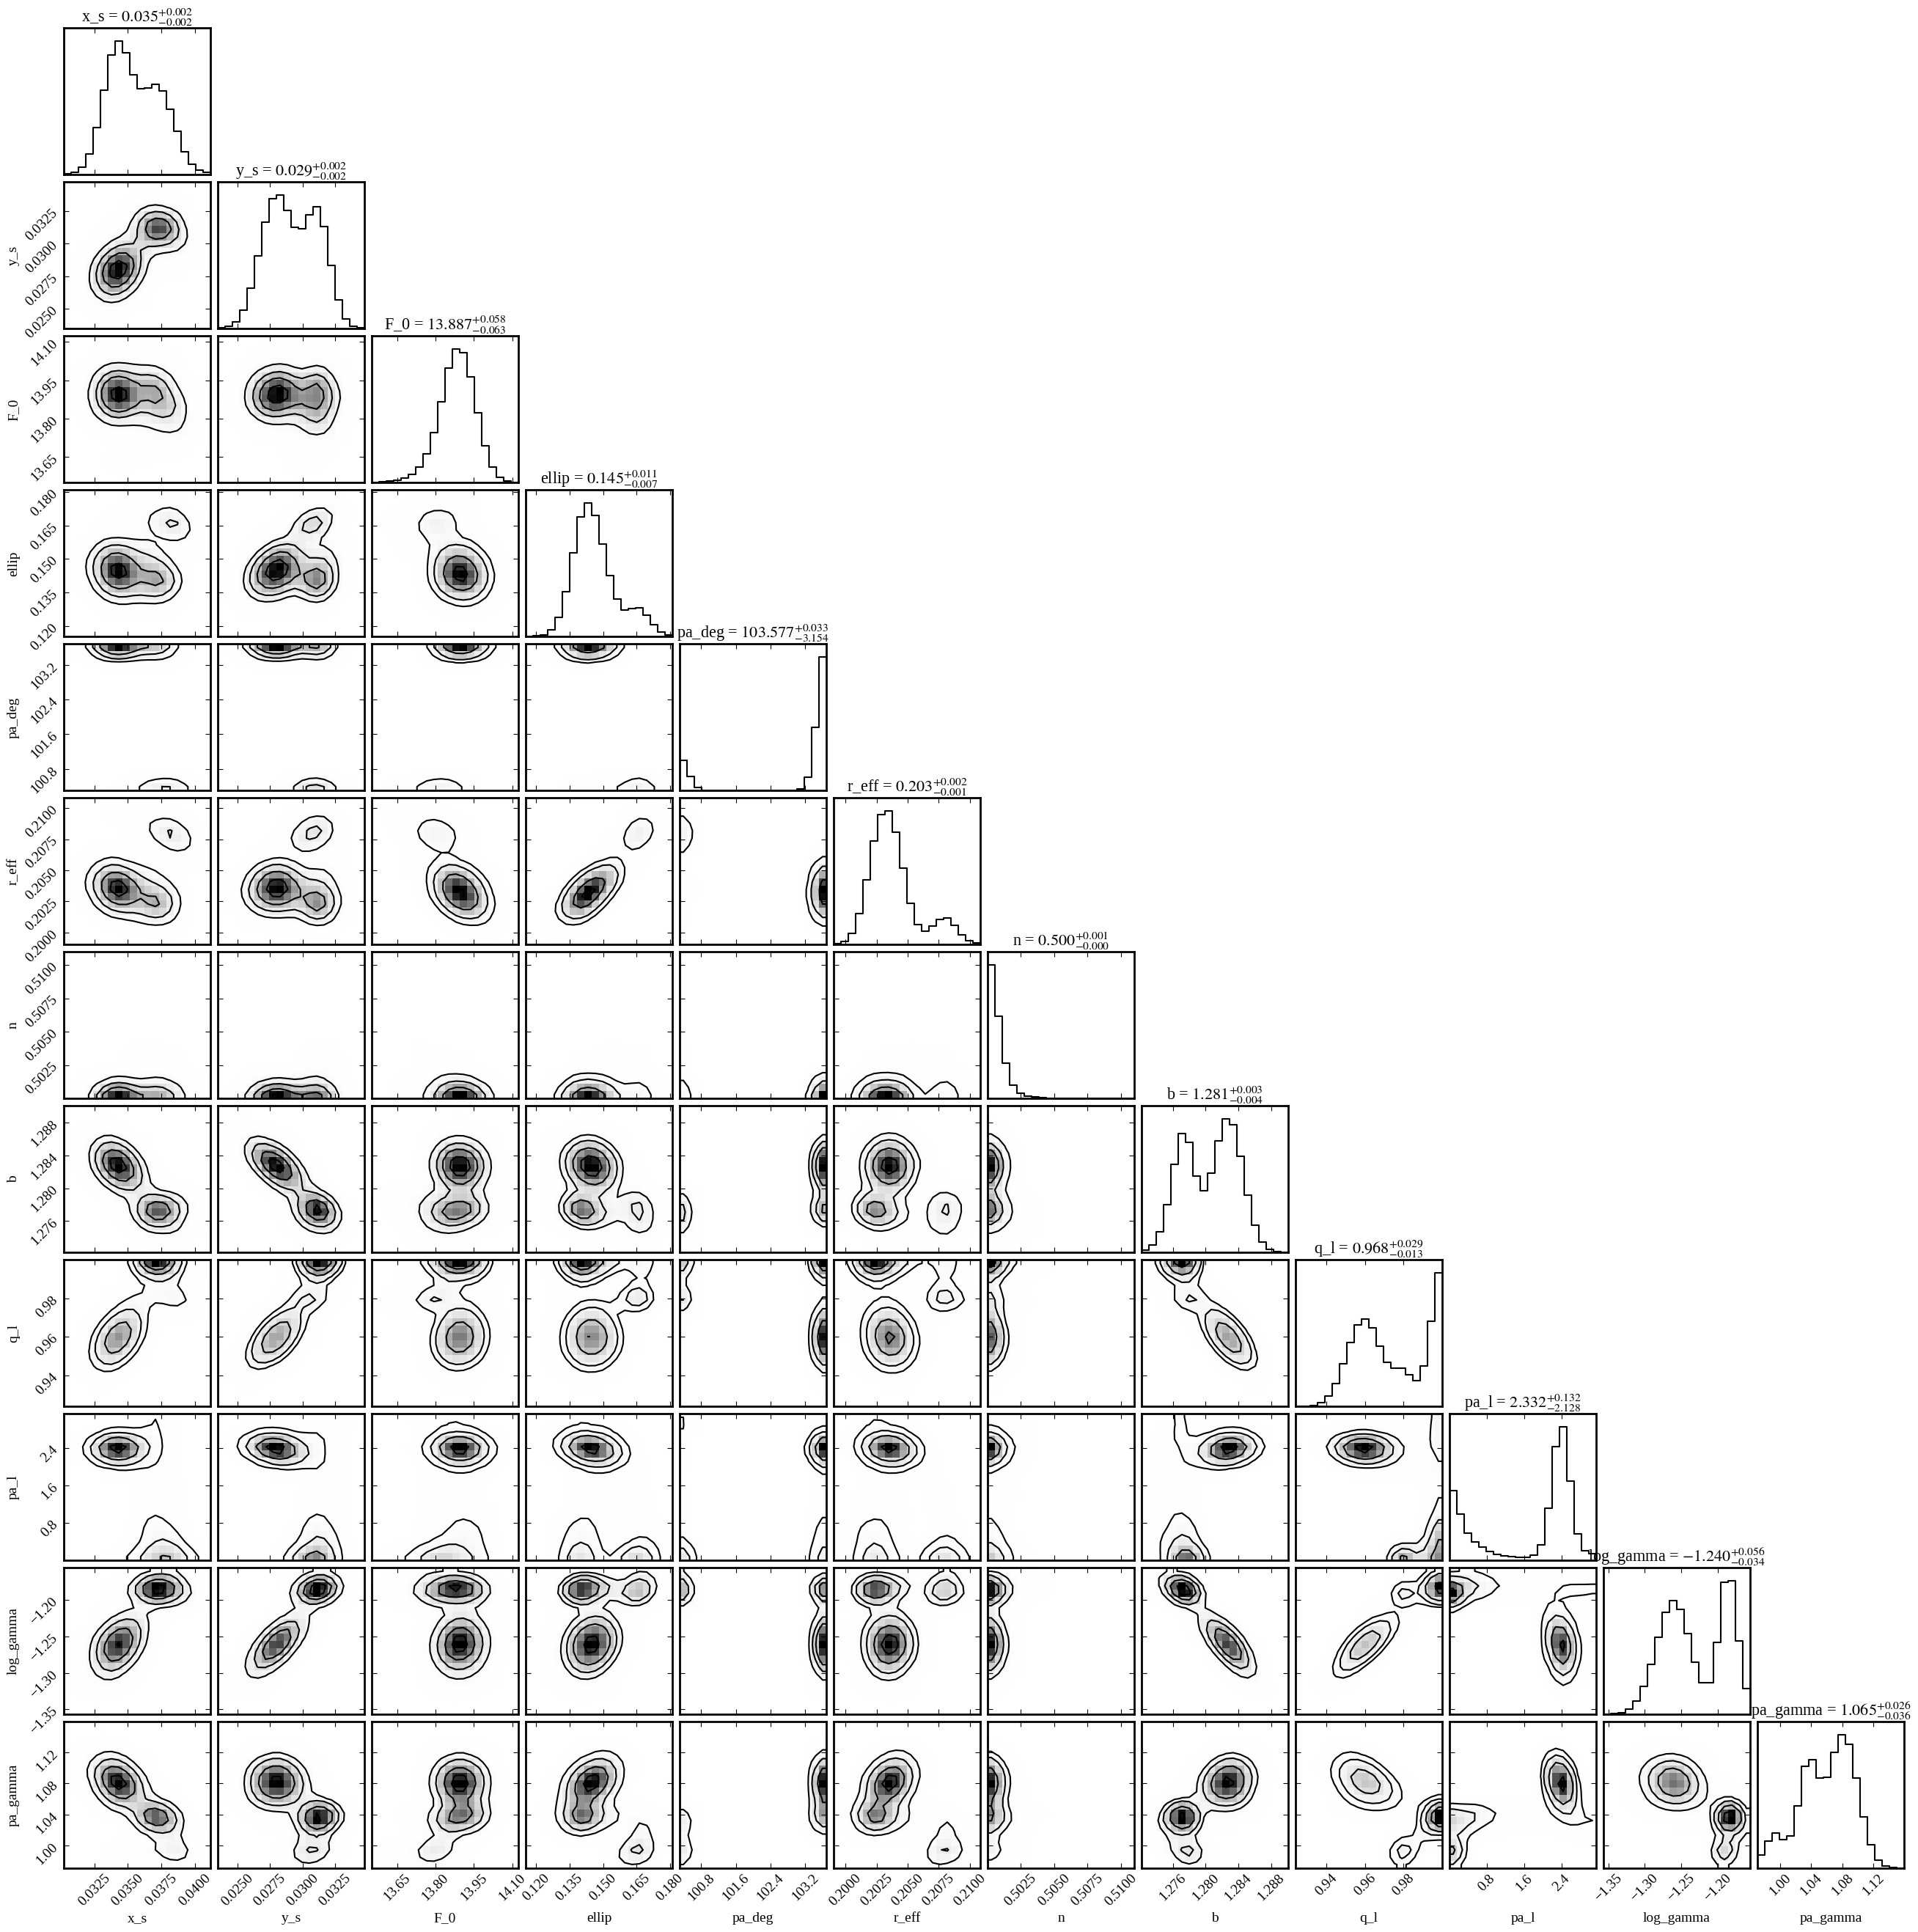


Saved corner plot: ./figure/corner_G09_cont_mom0_image.pdf

 Best-fit parameters
x_s           best=    0.0339
y_s           best=    0.0279
F_0           best=   13.9127
ellip         best=    0.1441
pa_deg        best=  103.5939
r_eff         best=    0.2035
n             best=    0.5001
b             best=    1.2829
q_l           best=    0.9611
pa_l          best=    2.4407
log_gamma     best=   -1.2634
pa_gamma      best=    1.0737

Completed comparison.


In [13]:
import numpy as np
import corner
import matplotlib.pyplot as plt

# ===============================
# 1. Load saved chain
# ===============================

savename = f"./mcmc_chain_{fit_data}_mom0_image.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names = list(npzfile["param_names"])

print("Loaded chain:")
print(" chain shape:", chain.shape)
print(" logprob shape:", logprob.shape)
print(" ndim:", len(param_names))


# ===============================
# 3. Flatten chain
# ===============================

nsteps, nwalkers, ndim = chain.shape
flat_chain = chain.reshape((-1, ndim))

print("\nFlattened chain shape:", flat_chain.shape)


# ===============================
# 4. Corner plot
# ===============================

fig = corner.corner(
    flat_chain,
    labels=param_names,
    show_titles=True,
    smooth=1.0,
    smooth1d=1.0,
    plot_density=True,
    plot_datapoints=False,
    title_fmt=".3f",
    title_kwargs={"fontsize": 16},
)

savename = f"./figure/corner_G09_{fit_data}_mom0_image.pdf"
fig.savefig(savename, dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

print(f"\nSaved corner plot: {savename}")

# ===============================
# 5. 真値 vs 最尤推定値
# ===============================

# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

print("\n==============================")
print(" Best-fit parameters")
print("==============================")

for name, best in zip(param_names, best_theta):
    print(f"{name:12s}  best={best:10.4f}")

print("\nCompleted comparison.")

## Compare models and observations

Saved to ./figure/maps_mcmc_cont_mom0_lens_fix.pdf


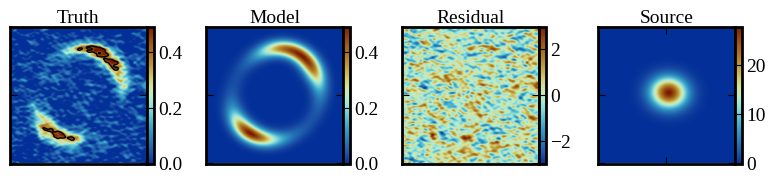

In [ ]:
# model with best-fit parameters
best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_2D_image(best_theta, ctx)

# Plot
# Some settings for plotting
vmax = np.nanmax(obsdata) * 0.9
width = 2
titles = ["Truth", "Model", "Residual", "Source"]


fig, axes = plt.subplots(1, 4, figsize=(width*4, width*1))
fig.subplots_adjust(wspace=0., hspace=0.0)
im0 = axes[0].imshow(obsdata, cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
axes[0].contour(obsdata/noisedata, levels=[8,16,32], colors='black', linewidths=1.0)
im1 = axes[1].imshow(best_lensed_cube_conv, cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
im2 = axes[2].imshow((obsdata - best_lensed_cube_conv) / noisedata, cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
im3 = axes[3].imshow(best_source, cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

for j in range(4):
    axes[j].set_title(titles[j], fontsize=14, pad=-2)
    divider = make_axes_locatable(axes[j])
    cax = divider.append_axes("right", size="5%", pad=0.)
    fig.colorbar([im0, im1, im2, im3][j], cax=cax)
    axes[j].set_xticklabels([])
    axes[j].set_yticklabels([])

    
fig.savefig(f"./figure/maps_mcmc_{fit_data}_lens_fix.pdf", dpi=200, bbox_inches="tight", pad_inches=0.05)
print(f"Saved to ./figure/maps_mcmc_{fit_data}_lens_fix.pdf")
plt.tight_layout()